# Merging the Two Cleaned Data Sets:

To combine your two cleaned datasets (Crime and Income) into a single .csv file, we need a common key to link them. Since the Crime Data is incident-based (Latitude/Longitude) and the Income Data is geography-based (Census Tract), the standard "common part of schema" for our research is the Census Tract or the Service Planning Area (SPA).

**The Merge Strategy: Mapping Areas to Income**

Since the raw crime data doesn't contain the tract ID, we will join them using the Service Planning Area (SPA). This allows you to associate every crime incident with the average income and economic category of its broader region.

In [1]:
import pandas as pd ,numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, month, year, when, count, desc, dayofmonth, to_date, broadcast

In [5]:
# 1. Start the Session if not running already:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark with the Postgres driver
spark = SparkSession.builder \
    .appName("LA-Crime-Income") \
    .getOrCreate()
    
# 2. Load the Cleaned Datasets:
df_crime = spark.read.parquet("CS226_project/crime_cleaned_local.parquet")
df_income = spark.read.csv("CS226_project/datasets/Median_Income_Cleaned.csv",header=True)

In [6]:
common_cols = list(set(df_crime.columns).intersection(set(df_income.columns)))
print(common_cols)

[]


In [7]:
df_crime.count(), df_income.count()

(733940, 2495)

In [5]:
# number of partitions in the computer:
print("npartitions =", df_crime.rdd.getNumPartitions())

# answer was 12 => Each one has around 18mil rows.

npartitions = 12


The crime dataset has much higher count than the income data set. Without any common column.
So I am going to use boradcasting and parallelism and make a joining-bridge.


In [6]:
#increase parallelism:
spark.conf.set("spark.sql.shuffle.partitions", "40")
df_crime = df_crime.repartition(40)
print("npartitions =", df_crime.rdd.getNumPartitions())


npartitions = 40


In [7]:
# 3. Create a Mapping Bridge
# In LA, LAPD Areas correspond to specific SPAs. 
# This 'Common Schema' allows the join to work.

df_crime_with_spa = df_crime.withColumn("spa", 
    when(col("AREA_NAME").isin("Central", "Rampart", "Newton", "Hollenbeck"), "SPA 4 - Metro")
    .when(col("AREA_NAME").isin("77th Street", "Southwest", "Southeast"), "SPA 6 - South")
    .when(col("AREA_NAME").isin("Hollywood", "Wilshire", "West LA", "Pacific"), "SPA 5 - West")
    .when(col("AREA_NAME").isin("Van Nuys", "West Valley", "North Hollywood", "Foothill", "Devonshire", "Mission", "Topanga"), "SPA 2 - San Fernando")
    .when(col("AREA_NAME").isin("Northeast"), "SPA 4 - Metro") 
    .otherwise("Other")
)

In [ ]:
# 4. Perform the broadcast Join:
# We join on 'spa' to bring med_hh_income and ami_category into the crime records
from pyspark.sql.functions import broadcast

df_merged = df_crime_with_spa.join(
    broadcast(df_income.select("spa", "med_hh_income", "ami_category").distinct()), 
    on="spa", 
    how="left"
)

df_merged.printSchema()

root
 |-- spa: string (nullable = false)
 |-- DR_NO: integer (nullable = true)
 |-- Date_Rptd: string (nullable = true)
 |-- DATE_OCC: string (nullable = true)
 |-- TIME_OCC: integer (nullable = true)
 |-- AREA: integer (nullable = true)
 |-- AREA_NAME: string (nullable = true)
 |-- Rpt_Dist_No: integer (nullable = true)
 |-- Part_1-2: integer (nullable = true)
 |-- Crm_Cd: integer (nullable = true)
 |-- Crm_Cd_Desc: string (nullable = true)
 |-- Mocodes: string (nullable = true)
 |-- Vict_Age: integer (nullable = true)
 |-- Vict_Sex: string (nullable = true)
 |-- Vict_Descent: string (nullable = true)
 |-- Premis_Cd: integer (nullable = true)
 |-- Premis_Desc: string (nullable = true)
 |-- Weapon_Used_Cd: integer (nullable = true)
 |-- Weapon_Desc: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Status_Desc: string (nullable = true)
 |-- Crm_Cd_1: integer (nullable = true)
 |-- Crm_Cd_2: integer (nullable = true)
 |-- Crm_Cd_3: integer (nullable = true)
 |-- Crm_Cd

In [9]:
print(df_merged.count(), len(df_merged.columns))

216096831 38


In [10]:
import os

folder_path = "CS226_project"
out_dir = os.path.join(folder_path, "LA_Crime_Income_Merged_Final_parquet")

(df_merged
 .write
 .mode("overwrite")
 .parquet(out_dir)
)

print(f"Saved Parquet dataset to: {out_dir}")

26/03/05 00:29:39 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/05 00:29:40 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/05 00:29:40 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 00:29:40 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/05 00:29:40 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/03/05 00:29:40 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/03/05 00:29:48 WARN GarbageCol

Saved Parquet dataset to: CS226_project/LA_Crime_Income_Merged_Final_parquet


# Read the merged File for analysis:

In [1]:
import pandas as pd ,numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, month, year, when, count, desc, dayofmonth, to_date, broadcast

In [2]:

# 1. Start the Session if not running already:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark with the Postgres driver
spark = SparkSession.builder \
    .appName("LA-Crime-Income") \
    .getOrCreate()

ERROR StatusLogger Could not determine local host name
 java.net.UnknownHostException: e40014039e74: e40014039e74: Temporary failure in name resolution
	at java.base/java.net.InetAddress.getLocalHost(InetAddress.java:1936)
	at org.apache.logging.log4j.core.util.NetUtils.getLocalHostname(NetUtils.java:56)
	at org.apache.logging.log4j.core.LoggerContext.lambda$setConfiguration$0(LoggerContext.java:615)
	at java.base/java.util.concurrent.ConcurrentHashMap.computeIfAbsent(ConcurrentHashMap.java:1708)
	at org.apache.logging.log4j.core.LoggerContext.setConfiguration(LoggerContext.java:615)
	at org.apache.logging.log4j.core.LoggerContext.reconfigure(LoggerContext.java:694)
	at org.apache.logging.log4j.core.LoggerContext.reconfigure(LoggerContext.java:711)
	at org.apache.logging.log4j.core.LoggerContext.start(LoggerContext.java:253)
	at org.apache.logging.log4j.core.impl.Log4jContextFactory.getContext(Log4jContextFactory.java:245)
	at org.apache.logging.log4j.core.impl.Log4jContextFactory.getC

ERROR StatusConsoleListener Could not determine local host name
 java.net.UnknownHostException: e40014039e74: e40014039e74: Temporary failure in name resolution
	at java.base/java.net.InetAddress.getLocalHost(InetAddress.java:1936)
	at org.apache.logging.log4j.core.util.NetUtils.getLocalHostname(NetUtils.java:56)
	at org.apache.logging.log4j.core.LoggerContext.lambda$setConfiguration$0(LoggerContext.java:615)
	at java.base/java.util.concurrent.ConcurrentHashMap.computeIfAbsent(ConcurrentHashMap.java:1708)
	at org.apache.logging.log4j.core.LoggerContext.setConfiguration(LoggerContext.java:615)
	at org.apache.logging.log4j.core.LoggerContext.reconfigure(LoggerContext.java:694)
	at org.apache.logging.log4j.core.LoggerContext.setConfigLocation(LoggerContext.java:679)
	at org.apache.spark.internal.Logging.initializeLogging(Logging.scala:139)
	at org.apache.spark.internal.Logging.initializeLogIfNecessary(Logging.scala:114)
	at org.apache.spark.internal.Logging.initializeLogIfNecessary$(Loggi

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 05:38:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/05 05:38:31 WARN MacAddressUtil: Failed to find a usable hardware address from the network interfaces; using random bytes: 52:5c:9f:ea:d6:cb:13:44


In [3]:
df = spark.read.parquet("CS226_project/LA_Crime_Income_Merged_Final_parquet")
df.printSchema()

root
 |-- spa: string (nullable = true)
 |-- DR_NO: integer (nullable = true)
 |-- Date_Rptd: string (nullable = true)
 |-- DATE_OCC: string (nullable = true)
 |-- TIME_OCC: integer (nullable = true)
 |-- AREA: integer (nullable = true)
 |-- AREA_NAME: string (nullable = true)
 |-- Rpt_Dist_No: integer (nullable = true)
 |-- Part_1-2: integer (nullable = true)
 |-- Crm_Cd: integer (nullable = true)
 |-- Crm_Cd_Desc: string (nullable = true)
 |-- Mocodes: string (nullable = true)
 |-- Vict_Age: integer (nullable = true)
 |-- Vict_Sex: string (nullable = true)
 |-- Vict_Descent: string (nullable = true)
 |-- Premis_Cd: integer (nullable = true)
 |-- Premis_Desc: string (nullable = true)
 |-- Weapon_Used_Cd: integer (nullable = true)
 |-- Weapon_Desc: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Status_Desc: string (nullable = true)
 |-- Crm_Cd_1: integer (nullable = true)
 |-- Crm_Cd_2: integer (nullable = true)
 |-- Crm_Cd_3: integer (nullable = true)
 |-- Crm_Cd_

26/03/05 05:38:43 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


# Analysis SQL queries :


In [4]:
# 1. Crime Trend Analysis:

# Crimes per Year
df.groupBy("Occured_Year").count().orderBy("Occured_Year").show()

# Crimes per Month (Seasonality)
df.groupBy("Occured_Month").count().orderBy("Occured_Month").show()

+------------+--------+
|Occured_Year|   count|
+------------+--------+
|        2020|44383362|
|        2021|46045959|
|        2022|53119894|
|        2023|49962784|
|        2024|22560808|
|        2025|   24024|
+------------+--------+

+-------------+--------+
|Occured_Month|   count|
+-------------+--------+
|            1|20393289|
|            2|19095595|
|            3|19047989|
|            4|18197734|
|            5|17805210|
|            6|17449384|
|            7|17845138|
|            8|17754029|
|            9|17218459|
|           10|17759303|
|           11|16792181|
|           12|16738520|
+-------------+--------+



26/03/05 05:37:03 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [15]:
# 2. Top 10 Crime Descriptions
df.groupBy("Crm_Cd_Desc").count().orderBy(desc("count")).show(10, truncate=False)

# 3. Crime by Victim Descent (Descent Code: H-Hispanic, W-White, B-Black, etc.)
df.groupBy("Vict_Descent").count().orderBy(desc("count")).show()

# 4.Average age of victims per crime category
df.groupBy("Crm_Cd_Desc").avg("Vict_Age").orderBy(desc("avg(Vict_Age)")).show(10)

+--------------------------------------------------------+--------+
|Crm_Cd_Desc                                             |count   |
+--------------------------------------------------------+--------+
|BATTERY - SIMPLE ASSAULT                                |21190746|
|THEFT OF IDENTITY                                       |19096003|
|BURGLARY FROM VEHICLE                                   |17932142|
|ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT          |14800764|
|INTIMATE PARTNER - SIMPLE ASSAULT                       |13796573|
|VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS) |13586066|
|THEFT PLAIN - PETTY ($950 & UNDER)                      |13010182|
|BURGLARY                                                |12113812|
|THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)     |10488806|
|THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD|7737396 |
+--------------------------------------------------------+--------+
only showing top 10 rows



+------------+--------+
|Vict_Descent|   count|
+------------+--------+
|           H|90634977|
|           W|53838623|
|           B|35376172|
|           O|19866457|
|           X| 5634473|
|           A| 5578457|
|           F| 1532123|
|           C| 1189721|
|           K| 1023336|
|           J|  382983|
|           V|  337772|
|           I|  287930|
|           Z|  191410|
|           P|   85224|
|           U|   47837|
|           D|   26568|
|           G|   20461|
|           L|   20096|
|           S|   12208|
|        NULL|    9461|
+------------+--------+
only showing top 20 rows



+--------------------+-----------------+
|         Crm_Cd_Desc|    avg(Vict_Age)|
+--------------------+-----------------+
|DISHONEST EMPLOYE...|             60.0|
|DRUNK ROLL - ATTEMPT|             58.0|
|DOCUMENT FORGERY ...|52.64909513328442|
|            LYNCHING| 52.3337091319053|
|BLOCKING DOOR IND...|51.81895093062606|
| PICKPOCKET, ATTEMPT|51.08675534991325|
|     ILLEGAL DUMPING|50.74276189888265|
|      TRAIN WRECKING|             50.0|
|  BUNCO, GRAND THEFT|48.42828222115821|
|     PURSE SNATCHING|48.03265784625691|
+--------------------+-----------------+
only showing top 10 rows



In [18]:
# 5. Top 10 Dangerous Areas
df.groupBy("AREA_NAME").count().orderBy(desc("count")).show(10)

# Most common premises for crime (Street, Apartment, Parking Lot, etc.)
df.groupBy("Premis_Desc").count().orderBy(desc("count")).show(10, truncate=False)

+-----------+--------+
|  AREA_NAME|   count|
+-----------+--------+
|    Topanga|18618242|
|   Van Nuys|18064860|
|    Central|17919645|
|West Valley|16741838|
|    Mission|16281680|
| Devonshire|15787918|
|   Foothill|13277374|
|  Southwest|11697770|
|     Newton|11492985|
|    Rampart|11369475|
+-----------+--------+
only showing top 10 rows



+--------------------------------------------+--------+
|Premis_Desc                                 |count   |
+--------------------------------------------+--------+
|SINGLE FAMILY DWELLING                      |50160136|
|STREET                                      |39340485|
|MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)|31104430|
|PARKING LOT                                 |14729316|
|SIDEWALK                                    |10194425|
|VEHICLE, PASSENGER/TRUCK                    |7788410 |
|OTHER BUSINESS                              |6418395 |
|DRIVEWAY                                    |3597835 |
|GARAGE/CARPORT                              |3435716 |
|DEPARTMENT STORE                            |2391649 |
+--------------------------------------------+--------+
only showing top 10 rows



In [28]:
# 6. Weapons vs crime :

# Check for presence of weapon (Weapon_Used_Cd is not null)
df_weapon = df.withColumn(
    "Has_Weapon",
    when(col("Weapon_Used_Cd").isNotNull(), "Yes").otherwise("No")
)

df_weapon.groupBy("Has_Weapon").count().show()

# Top weapons used in crimes
df.filter(col("Weapon_Desc").isNotNull()) \
    .groupBy("Weapon_Desc").count() \
    .orderBy(desc("count")).show(10, truncate=False)

# Weapon percentage
total = df.count()
df_weapon.groupBy("Has_Weapon") \
    .count() \
    .withColumn("percent", (col("count")/total)*100) \
    .show()


+----------+---------+
|Has_Weapon|    count|
+----------+---------+
|        No|129354572|
|       Yes| 86742259|
+----------+---------+



+----------------------------------------------+--------+
|Weapon_Desc                                   |count   |
+----------------------------------------------+--------+
|STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)|48153925|
|UNKNOWN WEAPON/OTHER WEAPON                   |8841391 |
|VERBAL THREAT                                 |6468157 |
|HAND GUN                                      |4985237 |
|KNIFE WITH BLADE 6INCHES OR LESS              |1843609 |
|SEMI-AUTOMATIC PISTOL                         |1794689 |
|OTHER KNIFE                                   |1574453 |
|UNKNOWN FIREARM                               |1357546 |
|MACE/PEPPER SPRAY                             |951974  |
|VEHICLE                                       |896267  |
+----------------------------------------------+--------+
only showing top 10 rows

+----------+---------+-----------------+
|Has_Weapon|    count|          percent|
+----------+---------+-----------------+
|        No|129354572|59.85954139234925

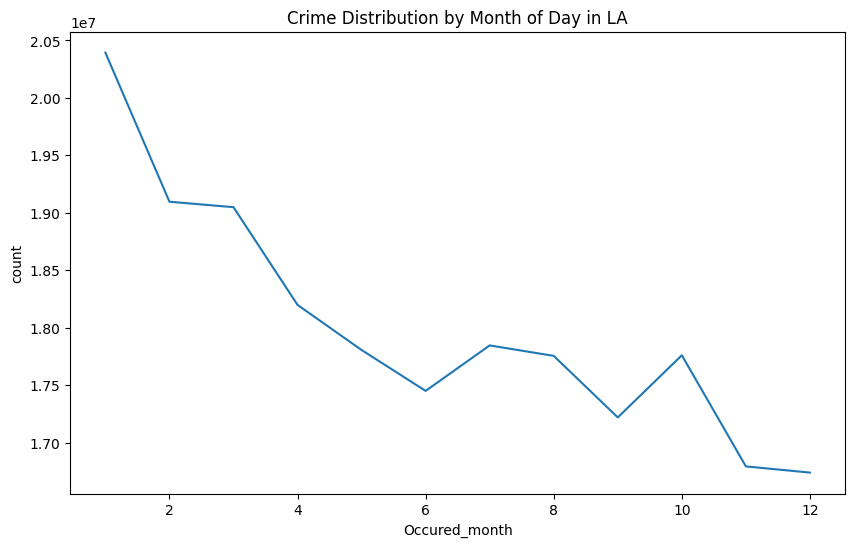

In [ ]:
# 7. Aggregate by Month for a line plot
monthly_crime = df.groupBy("Occured_month").count().orderBy("Occured_month").toPandas()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_crime, x="Occured_month", y="count")
plt.title("Crime Distribution by Month of Day in LA")
plt.show()


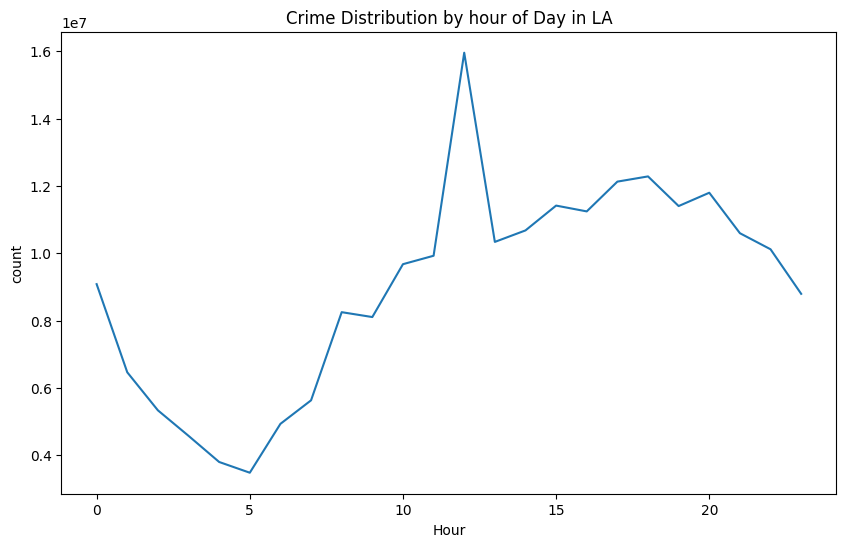

In [ ]:
# 8. Group by Hour and count occurrences
hourly_crime = df.groupBy("Hour").count().orderBy("Hour").toPandas()
plt.figure(figsize=(10,6))
sns.lineplot(data=hourly_crime, x="Hour", y="count")
plt.title("Crime Distribution by hour of Day in LA")
plt.show()

Analysis Based on SPA 

+--------------------+--------+
|                 spa|   count|
+--------------------+--------+
|SPA 2 - San Fernando|98771912|
|       SPA 4 - Metro|59207865|
|       SPA 6 - South|31918110|
|        SPA 5 - West|26099130|
|               Other|   99814|
+--------------------+--------+



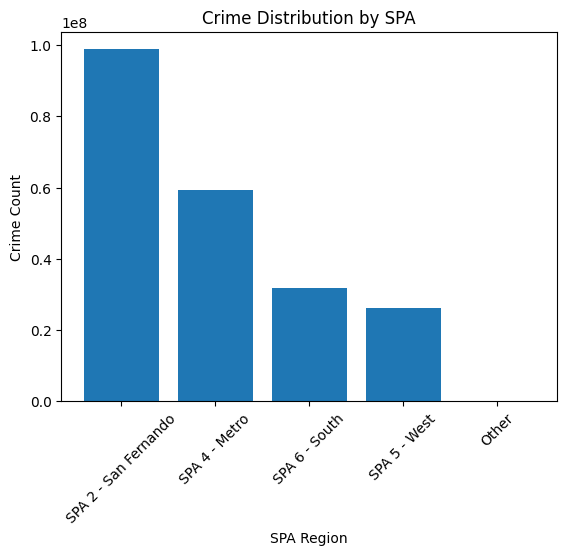

In [5]:
# 9. Which SPA regions experience the most crimes?
# This identifies high-crime geographic regions in LA
spa_crime = df.groupBy("spa").count().orderBy(desc("count"))
spa_crime.show()

pdf = spa_crime.toPandas()
plt.figure()
plt.bar(pdf["spa"], pdf["count"])
plt.xticks(rotation=45)
plt.xlabel("SPA Region")
plt.ylabel("Crime Count")
plt.title("Crime Distribution by SPA")
plt.show()

+--------------------+--------------------------------------------------------+--------+
|spa                 |Crm_Cd_Desc                                             |count   |
+--------------------+--------------------------------------------------------+--------+
|SPA 2 - San Fernando|THEFT OF IDENTITY                                       |10193394|
|SPA 2 - San Fernando|BATTERY - SIMPLE ASSAULT                                |8614548 |
|SPA 2 - San Fernando|BURGLARY FROM VEHICLE                                   |7339764 |
|SPA 2 - San Fernando|BURGLARY                                                |7089902 |
|SPA 4 - Metro       |BATTERY - SIMPLE ASSAULT                                |7030410 |
|SPA 2 - San Fernando|INTIMATE PARTNER - SIMPLE ASSAULT                       |6744648 |
|SPA 4 - Metro       |BURGLARY FROM VEHICLE                                   |6680235 |
|SPA 2 - San Fernando|VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS) |6150074 |
|SPA 2 - San Fernando

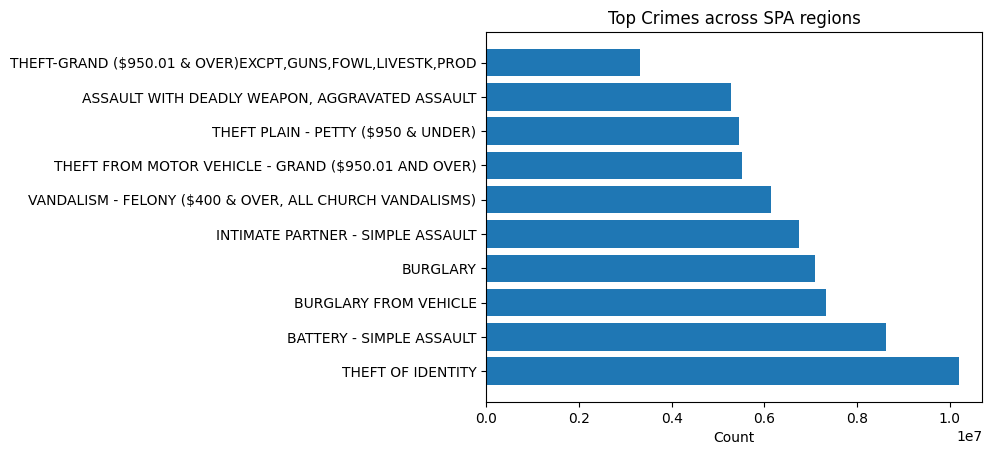

In [6]:
# 10. What types of crimes dominate each SPA?
crime_spa = df.groupBy("spa","Crm_Cd_Desc").count()
top_crime_spa = crime_spa.orderBy(desc("count"))
top_crime_spa.show(20, truncate=False)

pdf = top_crime_spa.limit(20).toPandas()
plt.figure()
plt.barh(pdf["Crm_Cd_Desc"], pdf["count"])
plt.xlabel("Count")
plt.title("Top Crimes across SPA regions")
plt.show()

+--------------------+------------------+-----------+
|                 spa|        avg_income|crime_count|
+--------------------+------------------+-----------+
|SPA 2 - San Fernando|100981.62662999348|   98771912|
|               Other|              NULL|      99814|
|       SPA 6 - South| 61994.00816326531|   31918110|
|        SPA 5 - West|126750.21628421557|   26099130|
|       SPA 4 - Metro| 77295.09748828811|   59207865|
+--------------------+------------------+-----------+



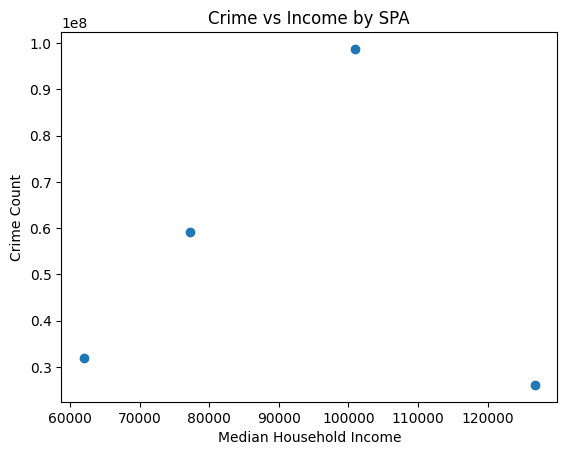

In [7]:
# 11. Do lower income SPA regions experience more crime?
from pyspark.sql.functions import avg

spa_income_crime = df.groupBy("spa") \
    .agg(
        avg("med_hh_income").alias("avg_income"),
        count("*").alias("crime_count")
    )

spa_income_crime.show()

pdf = spa_income_crime.toPandas()
plt.figure()
plt.scatter(pdf["avg_income"], pdf["crime_count"])
plt.xlabel("Median Household Income")
plt.ylabel("Crime Count")
plt.title("Crime vs Income by SPA")
plt.show()

+------------+--------------------+--------+
|Occured_Year|                 spa|   count|
+------------+--------------------+--------+
|        2024|               Other|   10703|
|        2023|       SPA 4 - Metro|14268165|
|        2020|        SPA 5 - West| 5359722|
|        2025|       SPA 4 - Metro|    5175|
|        2021|        SPA 5 - West| 5905386|
|        2023|       SPA 6 - South| 7235585|
|        2025|SPA 2 - San Fernando|   18428|
|        2020|SPA 2 - San Fernando|20521746|
|        2023|        SPA 5 - West| 5818734|
|        2024|       SPA 4 - Metro| 5522070|
|        2024|       SPA 6 - South| 3375365|
|        2023|SPA 2 - San Fernando|22617660|
|        2021|SPA 2 - San Fernando|20966728|
|        2024|        SPA 5 - West| 2860908|
|        2022|               Other|   23635|
|        2020|       SPA 4 - Metro|11625465|
|        2021|               Other|   22240|
|        2024|SPA 2 - San Fernando|10791762|
|        2021|       SPA 6 - South| 6641215|
|        2

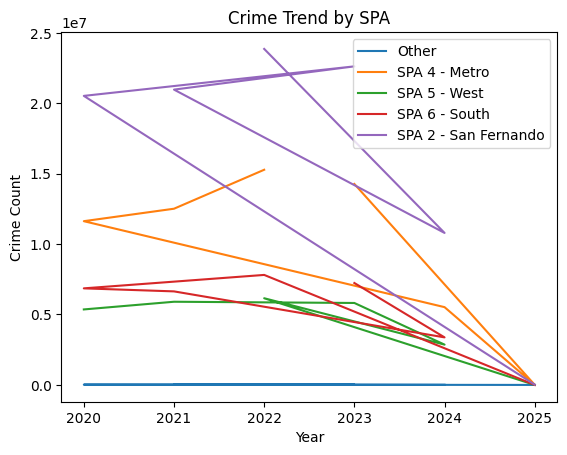

In [8]:
# 12. How crime evolves in different SPA regions.
spa_time = df.groupBy("Occured_Year","spa").count()
spa_time.show()

pdf = spa_time.toPandas()
plt.figure()
for spa in pdf["spa"].unique():
    subset = pdf[pdf["spa"] == spa]
    plt.plot(subset["Occured_Year"], subset["count"], label=spa)

plt.legend()
plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.title("Crime Trend by SPA")
plt.show()


+--------------------+----------+--------+
|                 spa|Has_Weapon|   count|
+--------------------+----------+--------+
|SPA 2 - San Fernando|       Yes|34522690|
|       SPA 6 - South|        No|15238265|
|        SPA 5 - West|       Yes| 8926722|
|       SPA 4 - Metro|       Yes|26572935|
|       SPA 4 - Metro|        No|32634930|
|        SPA 5 - West|        No|17172408|
|               Other|       Yes|   40067|
|               Other|        No|   59747|
|       SPA 6 - South|       Yes|16679845|
|SPA 2 - San Fernando|        No|64249222|
+--------------------+----------+--------+



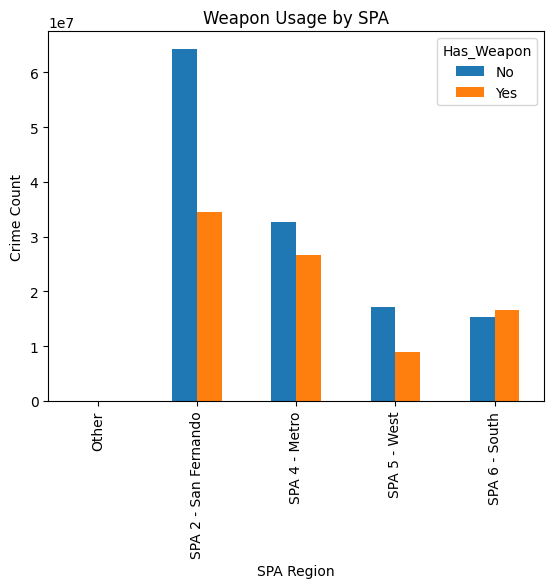

In [4]:
# 13. Which SPA regions experience more weapon-related crimes?
from pyspark.sql.functions import when
df_weapon = df.withColumn(
    "Has_Weapon",
    when(col("Weapon_Used_Cd").isNotNull(), "Yes").otherwise("No")
)

weapon_spa = df_weapon.groupBy("spa","Has_Weapon").count()
weapon_spa.show()


pdf = weapon_spa.toPandas()
pivot = pdf.pivot(index="spa", columns="Has_Weapon", values="count")
pivot.plot(kind="bar")
plt.xlabel("SPA Region")
plt.ylabel("Crime Count")
plt.title("Weapon Usage by SPA")
plt.show()

# Spatial queries:

In [25]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# 0) Clean coordinates + keep valid LA points
df_geo = (df
  .withColumn("LAT_d", F.col("LAT").cast("double"))
  .withColumn("LON_d", F.col("LON").cast("double"))
  .withColumn("geo_valid",
              F.when(F.col("LAT_d").between(33.5, 34.5) & F.col("LON_d").between(-119.0, -117.0), 1).otherwise(0))
  .filter(F.col("geo_valid") == 1)
)

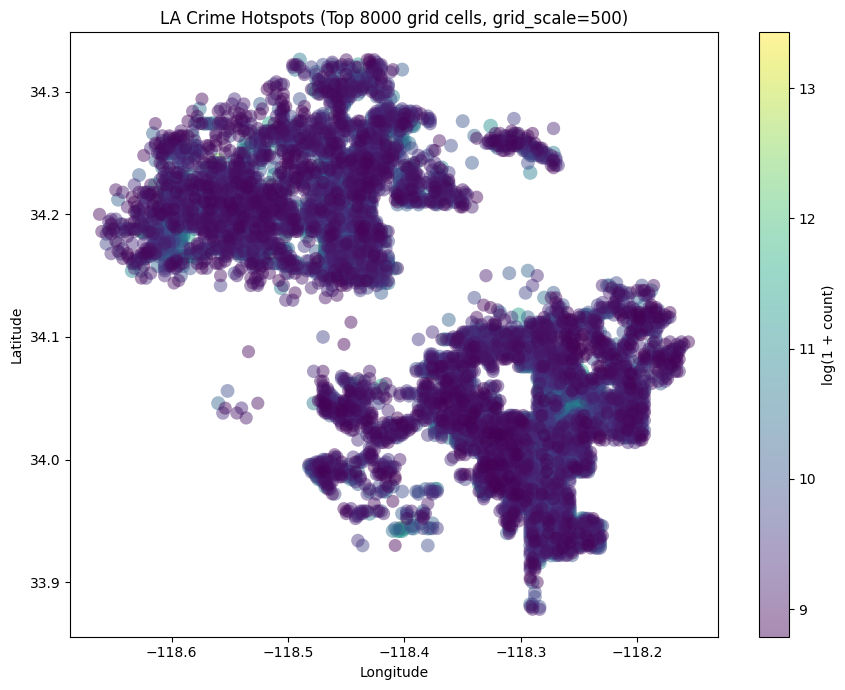

In [ ]:
# 1. Question: Where are the top spatial hotspots across LA?
# Top k-query
grid_scale = 500          # start with 200–500 for citywide
K = 8000                  # number of grid cells to plot

df_grid = (df_geo
  .withColumn("lat_grid", F.floor(F.col("LAT_d") * grid_scale) / grid_scale)
  .withColumn("lon_grid", F.floor(F.col("LON_d") * grid_scale) / grid_scale)
)

hotspots = (df_grid
  .groupBy("lat_grid","lon_grid")
  .count()
  .orderBy(F.desc("count"))
  .limit(K)
)

pdf = hotspots.toPandas()

# log transform makes hotspots pop without giant circles
pdf["logc"] = np.log1p(pdf["count"])

sizes = 10 * pdf["logc"]   # tune multiplier (5–30)

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    pdf["lon_grid"], pdf["lat_grid"],
    c=pdf["logc"], s=sizes,
    alpha=0.45, linewidths=0
)
plt.colorbar(sc, label="log(1 + count)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"LA Crime Hotspots (Top {K} grid cells, grid_scale={grid_scale})")
plt.tight_layout()
plt.show()


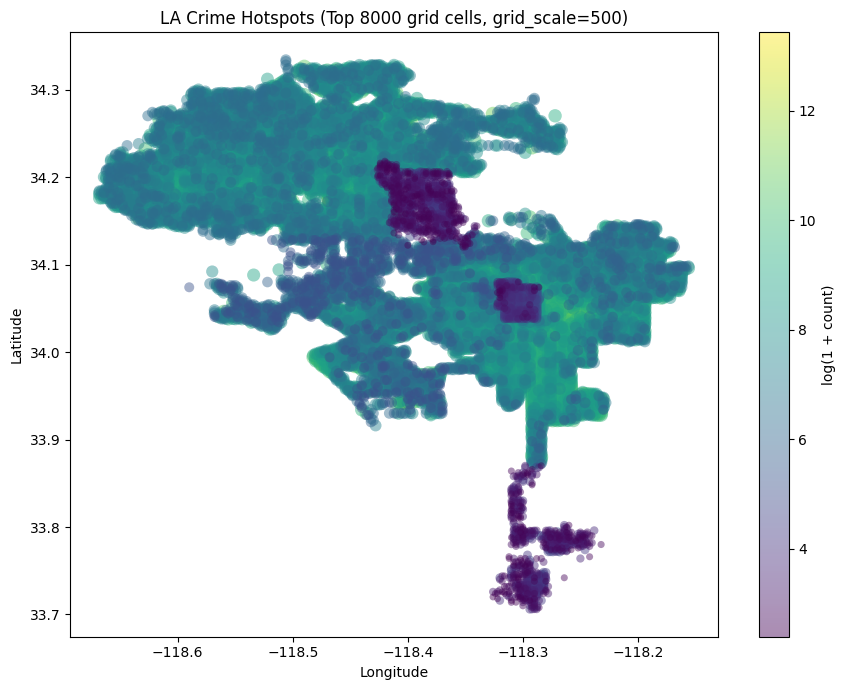

In [ ]:
# only meaningful hotspots instead of top-k:

min_count = 10
hotspots = (df_grid
  .groupBy("lat_grid","lon_grid")
  .count()
  .filter(F.col("count") >= min_count)
  .orderBy(F.desc("count"))
)

pdf = hotspots.toPandas()

# log transform makes hotspots pop without giant circles
pdf["logc"] = np.log1p(pdf["count"])

sizes = 10 * pdf["logc"]   # tune multiplier (5–30)

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    pdf["lon_grid"], pdf["lat_grid"],
    c=pdf["logc"], s=sizes,
    alpha=0.45, linewidths=0
)
plt.colorbar(sc, label="log(1 + count)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"LA Crime Hotspots (Top {K} grid cells, grid_scale={grid_scale})")
plt.tight_layout()
plt.show()

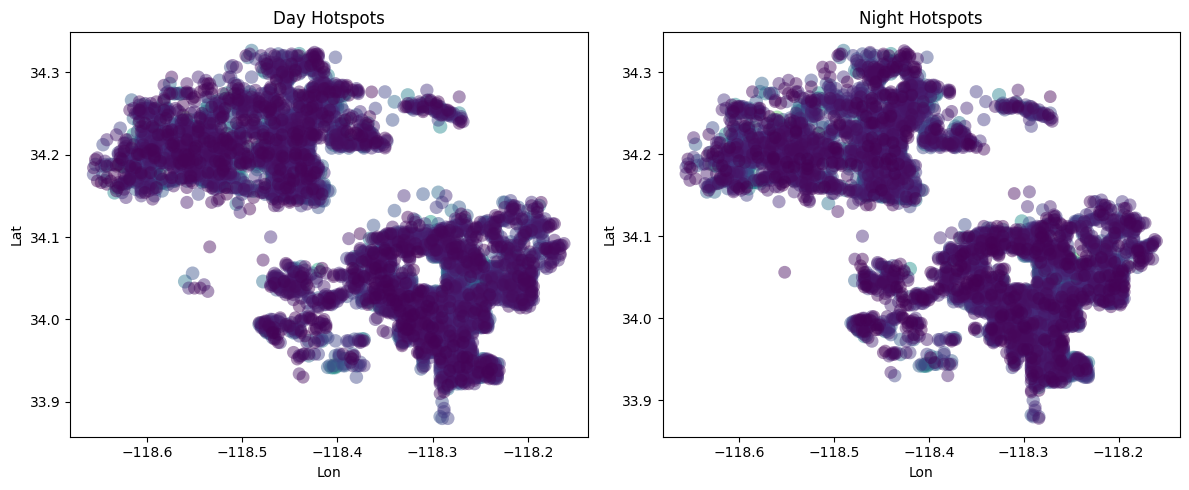

In [29]:
# Day vs Night comparison:

grid_scale = 500
K = 6000

df_grid = (df_geo
  .withColumn("lat_grid", F.floor(F.col("LAT_d") * grid_scale) / grid_scale)
  .withColumn("lon_grid", F.floor(F.col("LON_d") * grid_scale) / grid_scale)
  .withColumn("day_part", F.when((F.col("Hour")>=6) & (F.col("Hour")<18), "Day").otherwise("Night"))
)

def plot_part(part):
    hs = (df_grid.filter(F.col("day_part")==part)
          .groupBy("lat_grid","lon_grid").count()
          .orderBy(F.desc("count")).limit(K)).toPandas()
    hs["logc"] = np.log1p(hs["count"])
    return hs

day = plot_part("Day")
night = plot_part("Night")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(day["lon_grid"], day["lat_grid"], c=day["logc"], s=10*day["logc"], alpha=0.45, linewidths=0)
plt.title("Day Hotspots")
plt.xlabel("Lon"); plt.ylabel("Lat")


plt.subplot(1,2,2)
plt.scatter(night["lon_grid"], night["lat_grid"], c=night["logc"], s=10*night["logc"], alpha=0.45, linewidths=0)
plt.title("Night Hotspots")
plt.xlabel("Lon"); plt.ylabel("Lat")



plt.tight_layout()
plt.show()

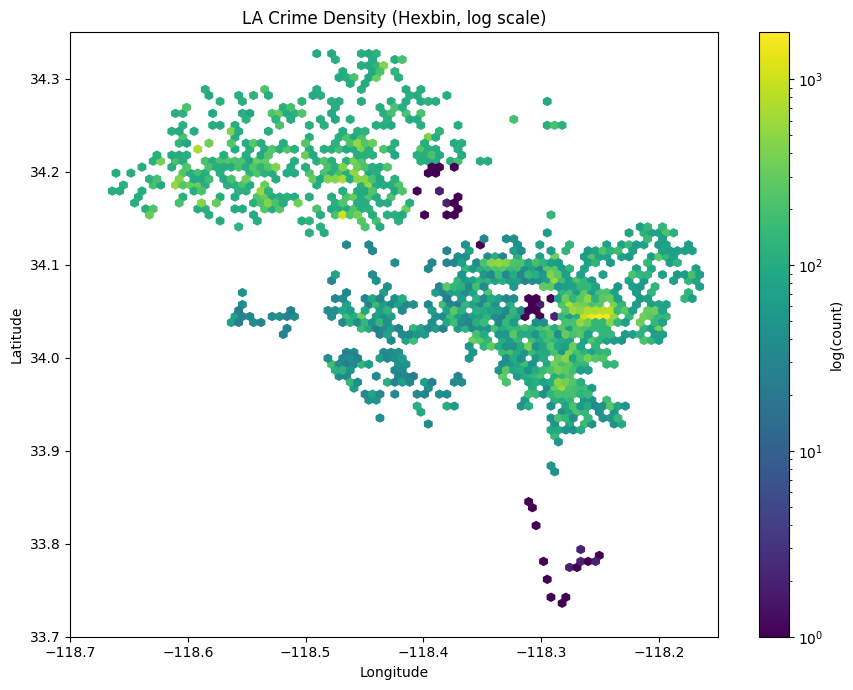

In [ ]:
# hexbin on sample a manageable number of points for plotting
pdf = (df_geo.select("LON_d","LAT_d")
       .sample(False, 0.2, seed=42)
       .limit(150000)
       .toPandas())

plt.figure(figsize=(9,7))
plt.hexbin(pdf["LON_d"], pdf["LAT_d"], gridsize=80, bins="log")
plt.colorbar(label="log(count)")
plt.xlim(-118.70, -118.15)
plt.ylim(33.70, 34.35)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("LA Crime Density (Hexbin, log scale)")
plt.tight_layout()
plt.show()

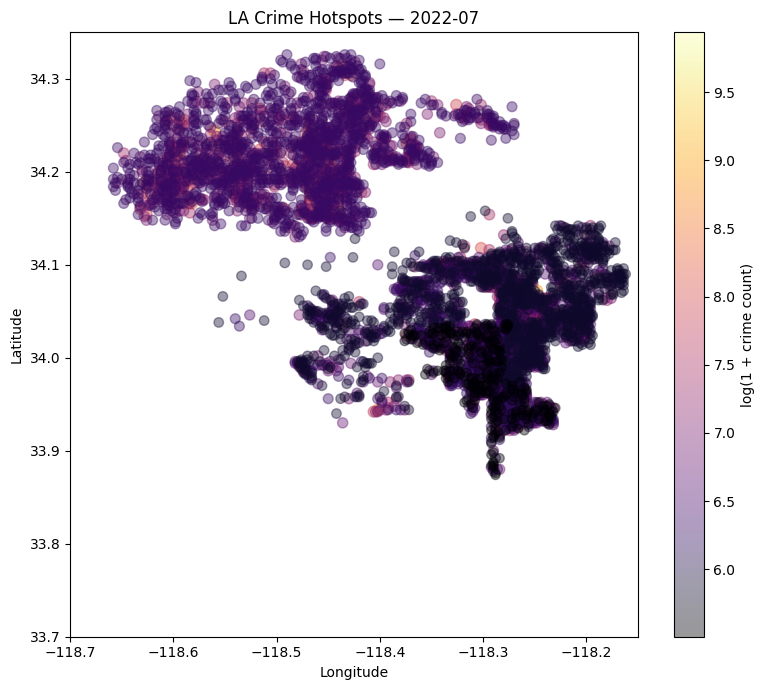

In [31]:
# 2. Hotspots by month:

year_pick, month_pick = 2022, 7  


K = 5000
hotspots_month = (df_grid
  .filter((F.col("Occured_Year") == year_pick) & (F.col("Occured_Month") == month_pick))
  .groupBy("lat_grid","lon_grid")
  .count()
  .orderBy(F.desc("count"))
  .limit(K)
)

pdf2 = hotspots_month.toPandas()
pdf2["logc"] = np.log1p(pdf2["count"])


plt.figure(figsize=(8,7))
sc = plt.scatter(
    pdf2["lon_grid"],
    pdf2["lat_grid"],
    c=pdf2["logc"],
    s=8 * pdf2["logc"],
    cmap="inferno",
    alpha=0.4
)

plt.colorbar(sc, label="log(1 + crime count)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"LA Crime Hotspots — {year_pick}-{month_pick:02d}")

# LA geographic bounds
plt.xlim(-118.7, -118.15)
plt.ylim(33.7, 34.35)

plt.tight_layout()
plt.show()

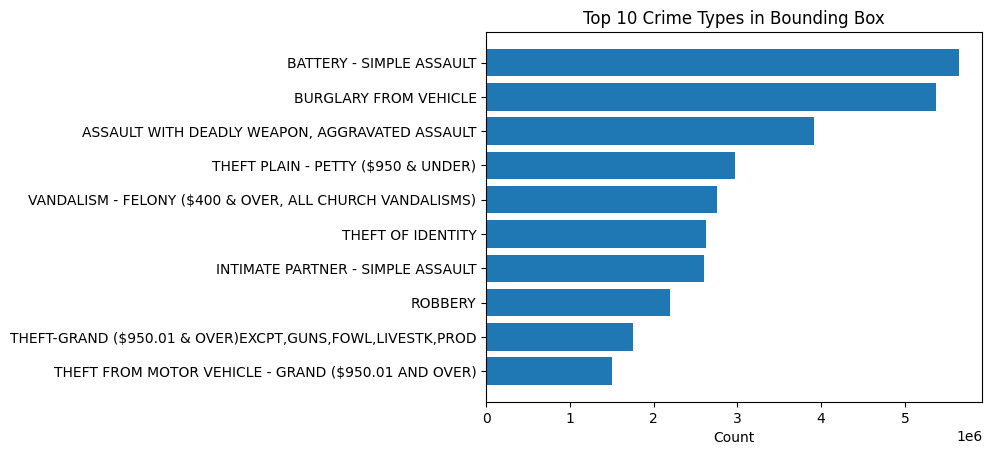

In [27]:
# 3. What are the dominant crime types in a chosen neighborhood area?

lat_min, lat_max = 34.00, 34.08
lon_min, lon_max = -118.30, -118.20

df_box = df_geo.filter(
    F.col("LAT_d").between(lat_min, lat_max) & F.col("LON_d").between(lon_min, lon_max)
)

top_crimes_box = (df_box
  .groupBy("Crm_Cd_Desc")
  .count()
  .orderBy(F.desc("count"))
  .limit(10)
)

pdf3 = top_crimes_box.toPandas()
plt.figure()
plt.barh(pdf3["Crm_Cd_Desc"][::-1], pdf3["count"][::-1])
plt.xlabel("Count")
plt.title("Top 10 Crime Types in Bounding Box")
plt.show()

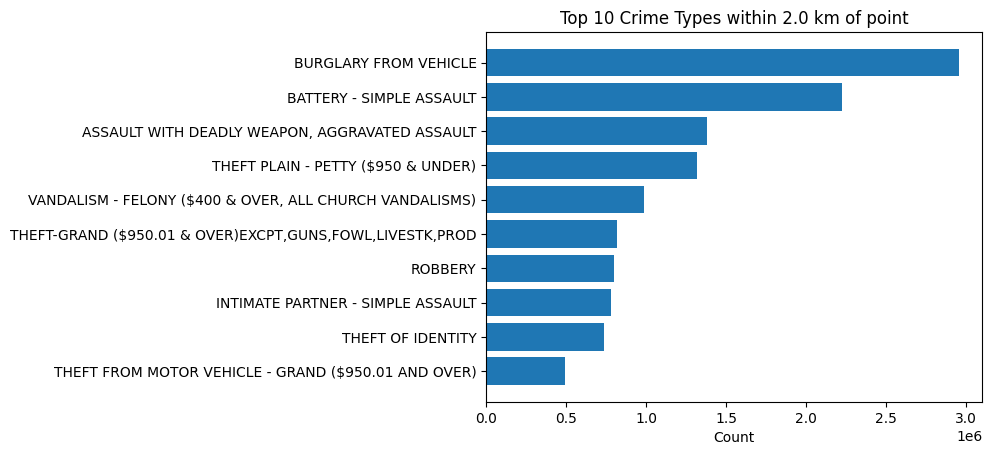

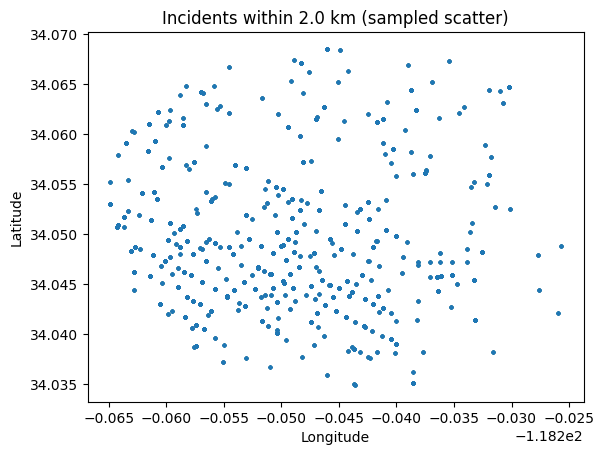

In [ ]:
# 4.What happens near a landmark (Downtown, USC, UCLA, etc.)?
# Crimes within R km of a point (radius query)

def haversine_km(lat0, lon0, lat_col, lon_col):
    r = 6371.0
    return 2*r*F.asin(F.sqrt(
        F.pow(F.sin((F.radians(lat_col) - F.radians(F.lit(lat0)))/2), 2) +
        F.cos(F.radians(F.lit(lat0))) * F.cos(F.radians(lat_col)) *
        F.pow(F.sin((F.radians(lon_col) - F.radians(F.lit(lon0)))/2), 2)
    ))

center_lat, center_lon = 34.0522, -118.2437  # Downtown LA 
R = 2.0  # km

df_radius = df_geo.withColumn("dist_km", haversine_km(center_lat, center_lon, F.col("LAT_d"), F.col("LON_d")))
df_near = df_radius.filter(F.col("dist_km") <= R)

# (A) Top crimes near the point
top_near = (df_near.groupBy("Crm_Cd_Desc").count().orderBy(F.desc("count")).limit(10))
pdf4a = top_near.toPandas()
plt.figure()
plt.barh(pdf4a["Crm_Cd_Desc"][::-1], pdf4a["count"][::-1])
plt.xlabel("Count")
plt.title(f"Top 10 Crime Types within {R} km of point")
plt.show()

# (B) Plot nearby incidents as a scatter (sample to keep plot light)
pdf4b = (df_near.select("LON_d","LAT_d")
         .sample(False, 0.2, seed=7)   # adjust fraction if needed
         .limit(50000)                 # hard cap for safety
         .toPandas())

plt.figure()
plt.scatter(pdf4b["LON_d"], pdf4b["LAT_d"], s=2)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Incidents within {R} km (sampled scatter)")
plt.show()

